# Setup


In [1]:
# Standard library imports
import time
import warnings

# Third-party imports (core data -> visualization)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb           

# Configuration & Settings
warnings.simplefilter(action='ignore', category=FutureWarning)

What we import:
- **`time`** is the standard-library stopwatch 
- **`warnings`** lets us silence noisy-but-harmless `FutureWarning` messages from the numerical libraries so the output stays readable (mostly for pandas df manipulations); `simplefilter(action='ignore', ...)` installs that filter globally.
- **`numpy`**  is the numerical engine: arrays, random number generation, and the least-squares solver 
- **`pandas`** gives us the `DataFrame`, a labelled table we use only at the end to assemble a tidy comparison of results. 
- **`matplotlib.pyplot`**  is the plotting library; every figure in this notebook goes through it. 
- **`xgboost`** is the gradient-boosting library

Important: none of these are conformal-prediction-specific - CP needs no special distributional machinery, it sits on top of whatever forecaster you already have.

In [2]:
# general settings
class CFG:
    SEED = 42                 # master random seed for reproducibility
    ALPHA = 0.10              # target miscoverage -> 1 - ALPHA = 90% nominal coverage
    P_LAGS = 2                # number of autoregressive lags in the covariate
    N_TRAIN = 300             # points used to FIT the base forecaster
    N_CAL = 300               # points used to CALIBRATE the conformal quantile
    N_TEST = 300              # points used to EVALUATE coverage and width
    N_REPS = 50               # Monte-Carlo repetitions in the simulation study
    img_dim1 = 13             # default figure width
    img_dim2 = 5              # default figure height

# display style
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (CFG.img_dim1, CFG.img_dim2)

np.random.seed(CFG.SEED)

The **`CFG`** class is a single namespace holding every constant the notebook depends on, so there are no unexplained "magic numbers" scattered through the code (constants defined on the fly are a pet peeve of mine, and by pet peeve I mean a psychotic hatred. Idgaf that it violates a Google style guide or sth ;-) 
-  **`SEED = 42`** seeds NumPy's global generator; fixing it means every run reproduces the same data and the same numbers. This should take care of most randomness, but if you want to be really super precise, you probably need to fix the seed in a few other places - random number generation in Python has something of a diversity problem 
- **`ALPHA = 0.10`** is the *miscoverage* level = we tolerate being wrong 10% of the time
- **`P_LAGS = 2`** our forecaster predicts each value from its two previous values. 
- The trio **`N_TRAIN / N_CAL / N_TEST = 300 / 300 / 300`** is the core of split conformal prediction: one block to *fit* the model, a disjoint block to *calibrate* the error threshold, and a final block to *test*. Keeping these separate and **chronological** (train is the oldest, test is the newest) is what makes the evaluation simulate real-life forecasting on unseen future data. Yes, it sounds obvious, but trust me: you will still mess it up and start peaking into the future if you're not careful.
-  **`N_REPS = 50`** is how many independent series we average over later to get stable estimates.

`plt.style.use("seaborn-v0_8")` applies a clean default theme, `rcParams["figure.figsize"]` sets a wide-and-short default so the graphs are actually readable for a human being.

The final `np.random.seed` call locks in reproducibility before any data is generated (insofar as possible in Python ML ;-)

# Utils

In [3]:
def conformal_quantile(scores, alpha):
    '''Finite-sample (1 - alpha) conformal quantile of a set of nonconformity scores.'''
    s = np.sort(scores)
    n = len(s)
    k = int(np.ceil((1 - alpha) * (n + 1)))   # finite-sample rank correction
    if k > n:
        return np.inf                          # not enough points -> unbounded interval
    return s[max(k, 1) - 1]

Most important function in conformal prediction:
- Given a 1-D array of *nonconformity scores* (absolute residuals `|y - prediction|` measured on the calibration set) and a miscoverage level `alpha`, it returns the threshold `q` such that roughly `1 - alpha` of the scores fall at or below it. We sort the scores, then pick the element at rank `k = ceil((1 - alpha)(n + 1))`.
- A "naive" empirical quantile would take the `(1 - alpha)`-th fraction of `n` points. The conformal correction inflates this slightly: it reserves a "slot" for the unseen test point, treating the calibration scores *and* the future score as one exchangeable pool of `n + 1` values. This adjustment upgrades an asymptotic statement into a **finite-sample guarantee**: with this `k`, the interval `[prediction - q, prediction + q]` provably covers the truth with probability at least `1 - alpha` whenever the data are exchangeable.
- When `1 - alpha` is so high (or `n` so small) that `k` exceeds `n`, no observed score is large enough to promise the coverage => **infinite interval** . Returning `np.inf` makes that explicit.

In [4]:
def weighted_conformal_quantile(scores, weights, test_weight, alpha):
    '''Weighted (1 - alpha) conformal quantile. Calibration points carry unequal weight.'''
    s = np.append(scores, np.inf)                 # the unseen test score sits at +inf
    w = np.append(weights, test_weight).astype(float)
    w = w / w.sum()                               # normalise weights to sum to 1
    order = np.argsort(s)
    s, w = s[order], w[order]
    cum = np.cumsum(w)
    idx = min(np.searchsorted(cum, 1 - alpha, side="left"), len(s) - 1)
    return s[idx]

This function generalises the quantile to the case where calibration points are **not** equally trustworthy:
- Each calibration score `s_i` gets a non-negative weight `w_i`. We append the test point as a score of `+inf` with its own `test_weight`, normalise all weights to sum to one, then walk up the sorted scores accumulating weight until we first reach the `1 - alpha` mass. That score is the weighted quantile.
- The reason we include `+inf` test slot is that it accounts for the unknown future point inside the weighted pool. If the calibration weights are too concentrated on too few points, the cumulative mass can only cross `1 - alpha` at the `+inf` slot => yields an unbounded interval.
- With all weights equal, this collapses back to ordinary conformal prediction. If more recent points are weighted higher, the quantile is driven by *recent* errors.

In [5]:
def interval_metrics(y, lower, upper, alpha):
    '''Coverage, mean width, and the Winkler interval score for a batch of intervals.'''
    covered = (y >= lower) & (y <= upper)
    coverage = float(np.mean(covered))
    width = float(np.mean(upper - lower))
    penalty = np.where(y < lower, (2 / alpha) * (lower - y),
              np.where(y > upper, (2 / alpha) * (y - upper), 0.0))
    winkler = float(np.mean((upper - lower) + penalty))
    return {"coverage": round(coverage, 3),
            "width": round(width, 3),
            "winkler": round(winkler, 3)}

This function is a scorecard, allowing to balance validity and efficiency (you can always cover everything with an infinitely wide interval  ;-)
- **Coverage** is the empirical fraction of test points that land inside their interval. A valid 90% method should sit near `0.90`
- **Width** is the mean interval length: among methods that *are* valid, the one with the smaller width is sharper and more useful. 
- **Winkler score** (the interval score) is the tie-breaker that combines both: it charges you the width of every interval *plus* a penalty of `(2/alpha) * distance` whenever the truth escapes the interval. It rewards intervals that are tight *and* honest, and punishes the cheap trick of inflating width to buy coverage. **Lower Winkler is better.** We round to three decimals and return a dict so results slot straight into a table.

In [6]:
def chronological_split(X, y, n_train, n_cal, n_test):
    '''Split lagged design matrix into train / calibration / test blocks, in time order.'''
    tr = slice(0, n_train)
    ca = slice(n_train, n_train + n_cal)
    te = slice(n_train + n_cal, n_train + n_cal + n_test)
    return (X[tr], y[tr]), (X[ca], y[ca]), (X[te], y[te])

A one-line helper for a very fundamental rule: **splits are chronological, never random**. 
The oldest `n_train` rows fit the model, the `n_cal` calibrate the quantile, and the final `n_test` are held out for evaluation. The function returns three `(X, y)` tuples carved out with `slice` objects.

In [7]:
def plot_intervals(y, lower, upper, point=None, title="", ax=None):
    '''Overlay observed series, the prediction band, and any points the band misses.'''
    if ax is None:
        fig, ax = plt.subplots()
    t = np.arange(len(y))
    ax.plot(t, y, color="C0", lw=2, label="observed")
    if point is not None:
        ax.plot(t, point, color="red", lw=1, alpha=0.7, label="point forecast")
    ax.fill_between(t, lower, upper, color="green", alpha=0.20, label="90% interval")
    miss = (y < lower) | (y > upper)
    ax.scatter(t[miss], y[miss], color="red", s=18, zorder=3, label="missed")
    cov = np.mean(~miss)
    ax.set_title(f"{title}  (coverage = {cov:.2f})")
    ax.legend(loc="upper left", fontsize=8)
    return ax

The plotting wrapper we reuse for every method: it draws the **observed series** as a solid blue line (`lw=2`), (optionally) the **point forecast** as a thin red line, shades the **90% interval** as a translucent green band, and marks every **missed** point ( where the truth fell outside the band) as a red scatter sitting on top (`zorder=3`).

 The realised coverage is printed in the title so you can read validity at a glance. 

# Groundwork: data, forecaster, and the exchangeability problem

Conformal prediction is a *wrapper*, so we need two things underneath it: data, and a point forecaster to wrap. 

In [8]:
def simulate_dgp(name, n, rng, shift=1.0):
    '''Generate one realisation of a named data-generating process of length n.'''
    e = rng.normal(0, 1, size=n)         # i.i.d. standard-normal innovations
    y = np.zeros(n)
    if name == "AR(1)":                  # weak temporal dependence, stationary
        for t in range(1, n):
            y[t] = 0.8 * y[t - 1] + e[t]
    elif name == "ARMA(1,1)":            # slightly longer memory, stationary
        for t in range(1, n):
            y[t] = 0.5 * y[t - 1] + e[t] + 0.4 * e[t - 1]
    elif name == "Mean-Shift":           # abrupt, permanent distribution shift
        t_star = (2 * n) // 3            # shift lands exactly at the first test point
        mu = np.where(np.arange(n) >= t_star, shift, 0.0)
        y = mu + e
    elif name == "GARCH(1,1)":           # volatility clustering (heteroscedastic)
        for t in range(1, n):
            sigma2 = 0.4 + 0.5 * y[t - 1] ** 2
            y[t] = np.sqrt(sigma2) * e[t]
    else:
        raise ValueError(f"unknown process: {name}")
    return y

These four processes are chosen to probe the two ways time series break exchangeability:
- The first two are **stationary and weakly dependent**: the "easy" regime where standard CP should still work.
- **AR(1)**, `y_t = 0.8 y_{t-1} + e_t`, has simple autocorrelation: each value is a damped echo of the last plus fresh noise. 
- **ARMA(1,1)** adds a moving-average term `0.4 e_{t-1}`, giving slightly richer memory. 
- Both forget their past quickly (they are *β-mixing* for the mathematically inclined), so the temporal dependence is mild.
- The last two are the stress tests. 
- **Mean-Shift** is pure noise around a level that **jumps permanently** by `shift = 1.0` two-thirds of the way through => engineered so the break coincides with the very first test point. This is *distribution shift*: the calibration block and the test block come from genuinely different processes, and no reweighting of old data can know about it. 
- **GARCH(1,1)** keeps a constant mean but its *variance* clusters — `sigma2 = 0.4 + 0.5 y_{t-1}^2` means a big move follows a big move,  so calm and turbulent regimes alternate. A single fixed interval width cannot be right in both.
- every process is driven by the same i.i.d. innovations `e`; the `name` selects how those innovations are wired into a series. 
- Passing an explicit `rng` (a NumPy random generator) keeps each realisation reproducible.

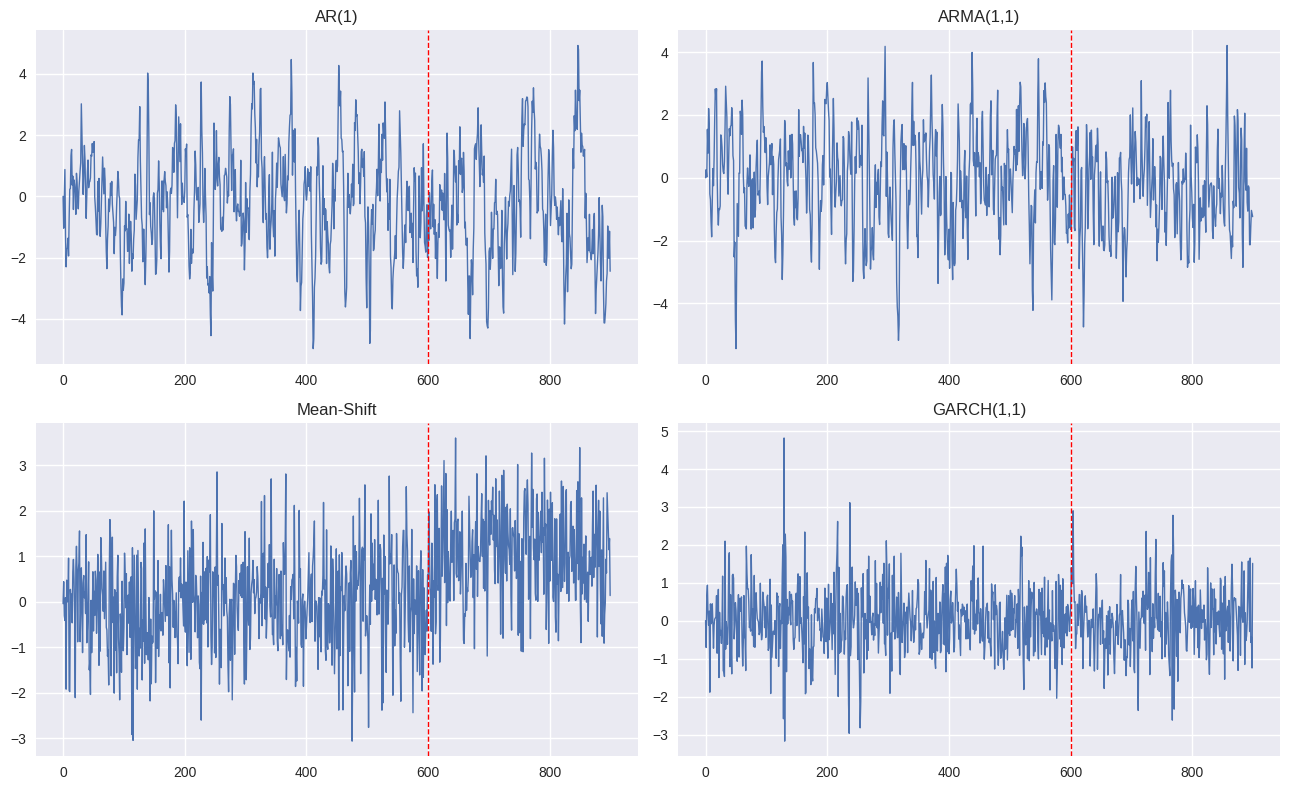

In [9]:
rng = np.random.default_rng(CFG.SEED)
fig, axes = plt.subplots(2, 2, figsize=(CFG.img_dim1, CFG.img_dim2 * 1.6))
for ax, name in zip(axes.ravel(), ["AR(1)", "ARMA(1,1)", "Mean-Shift", "GARCH(1,1)"]):
    series = simulate_dgp(name, 900, rng)
    ax.plot(series, lw=1)
    ax.axvline(600, color="red", ls="--", lw=1)   # where the test block begins
    ax.set_title(name)
plt.tight_layout()

In [10]:
def make_lags(y, p):
    '''Build an autoregressive design matrix: each row holds the p preceding values.'''
    n = len(y)
    X = np.column_stack([y[p - 1 - k: n - 1 - k] for k in range(p)])  # cols: y_{t-1}..y_{t-p}
    target = y[p:]
    return X, target

demo = simulate_dgp("AR(1)", 900 + CFG.P_LAGS, np.random.default_rng(0))
X_demo, y_demo = make_lags(demo, CFG.P_LAGS)
pd.DataFrame(X_demo[:3], columns=["y_{t-1}", "y_{t-2}"]).assign(target=y_demo[:3]).head(3)

,y_{t-1},y_{t-2},target
0,-0.132105,0.000000,0.534739
1,0.534739,-0.132105,0.532691
2,0.532691,0.534739,-0.109516


A predictive model needs features (duh): for a univariate series the natural covariate is the recent past => the **`make_lags`** function turns a single series into a supervised problem; row `t` holds the `p` previous values `(y_{t-1}, y_{t-2})` as inputs and `y_t` as the target. We lose the first `p` rows (they have insufficient history), which is why we simulate `900 + P_LAGS` points to end up with 900 usable rows for the 300/300/300 split.

The `head(3)` sanity check confirms the alignment: in each row the `target` is the value that *follows* the two lagged inputs. This is the covariate `X_t` referred to throughout — it "collects past lags."

In [11]:
def fit_arls(X, y):
    '''Fit an autoregressive least-squares forecaster (intercept + p lag coefficients).'''
    A = np.column_stack([np.ones(len(X)), X])
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)
    return coef

def predict_arls(coef, X):
    A = np.column_stack([np.ones(len(X)), X])
    return A @ coef

The base forecaster is the simplest non-trivial model: an **autoregression fit by least squares (AR-LS)**. The `fit_arls`  function prepends a column of ones (the intercept) to the lag matrix and calls `np.linalg.lstsq`, which solves for the coefficient vector that minimises squared error in closed form. `predict_arls` applies those fixed coefficients to new rows.

By fitting AR-LS a single time on the training block and then freezing it, we force the conformal machinery to do all the adapting. In particular, the frozen model will **not** track the mean shift on its own: its residuals will simply become biased => any method that maintains coverage is doing it via calibration, not a smarter model. 

mean |residual|  cal=0.854  test=0.885


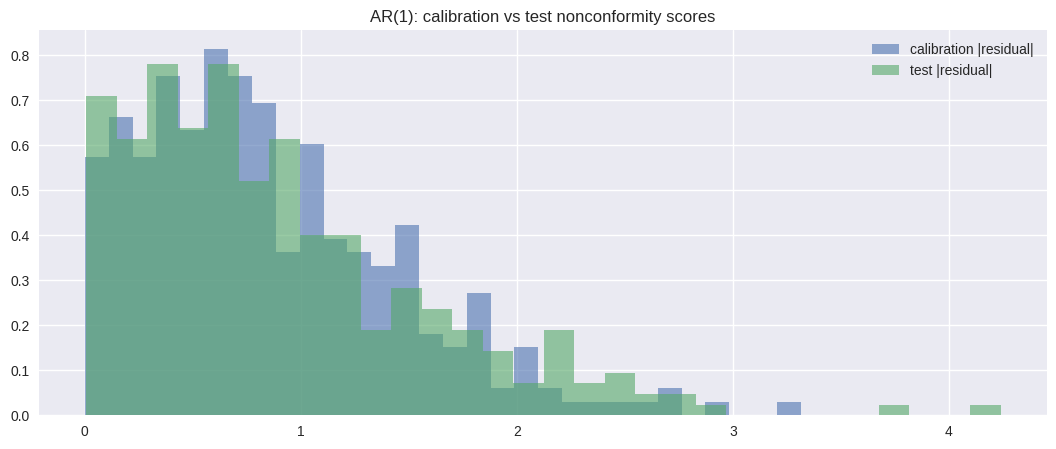

In [12]:
# Fit once on AR(1) training data, inspect residuals on calibration vs test
ar = simulate_dgp("AR(1)", 900 + CFG.P_LAGS, np.random.default_rng(1))
X, yt = make_lags(ar, CFG.P_LAGS)
(Xtr, ytr), (Xca, yca), (Xte, yte) = chronological_split(
    X, yt, CFG.N_TRAIN, CFG.N_CAL, CFG.N_TEST)

coef = fit_arls(Xtr, ytr)
res_cal = np.abs(yca - predict_arls(coef, Xca))
res_test = np.abs(yte - predict_arls(coef, Xte))

fig, ax = plt.subplots()
ax.hist(res_cal, bins=30, alpha=0.6, density=True, label="calibration |residual|")
ax.hist(res_test, bins=30, alpha=0.6, density=True, label="test |residual|")
ax.set_title("AR(1): calibration vs test nonconformity scores")
ax.legend()
print(f"mean |residual|  cal={res_cal.mean():.3f}  test={res_test.mean():.3f}")

We fit AR-LS on the training block and compute the **nonconformity scores**: absolute residuals on the calibration and test blocks separately, then overlay their histograms.

For a stationary process (which AR(1) is) the two distributions sit almost on top of each other: the errors the model makes on calibration data are statistically the same as the errors it makes on test data. That overlap *is* (approximately ;-) exchangeability, and it is the reason the calibration quantile will transfer to the test set. 

Spoiler alert: when we reach the mean-shift process, these two histograms will pull apart, the calibration scores will sit to the left of the test scores, and the fixed quantile computed on the left will be far too small for the right.

# The conformal forecasting ladder

We now climb the five methods. To make them directly comparable, each one wraps the **same frozen AR-LS forecaster** and runs on the **same AR(1) realisation** above, using the identical fit -> calibrate -> predict -> evaluate -> plot sequence. Only the calibration logic changes from rung to rung. We start from the plain baseline and add one idea at a time.

## SCP — Split Conformal Prediction

The baseline. Fit the model on the training block, measure its typical error on a disjoint calibration block, and build a single fixed-width interval around every future prediction.

In [13]:
def scp_interval(coef, X_cal, y_cal, X_test, alpha):
    '''Standard split conformal: one fixed quantile from calibration residuals.'''
    scores = np.abs(y_cal - predict_arls(coef, X_cal))      # nonconformity scores
    q = conformal_quantile(scores, alpha)                   # the (1-alpha) threshold
    point = predict_arls(coef, X_test)
    return point, point - q, point + q

The full recipe in four lines. **First**, compute nonconformity scores on the calibration block — the absolute residuals `|y_cal - prediction|`, our measure of how "strange" each point is to the fitted model. **Next**, collapse them to a single threshold `q` with `conformal_quantile`: the error level that `1 - alpha` of the calibration points did not exceed. **Then** form the point forecast on the test block and **finally** invert the score into an interval `[point - q, point + q]`. Because the absolute-residual score is symmetric, the interval is symmetric too — the same `q` is added and subtracted at every test step.

The defining feature, and ultimately the limitation, is that `q` is computed **once** and never moves. If the test data behave like the calibration data, that is exactly right and beautifully cheap. If they don't, this single number is stuck in the past.

In [14]:
point, lo, hi = scp_interval(coef, Xca, yca, Xte, CFG.ALPHA)
metrics_scp = interval_metrics(yte, lo, hi, CFG.ALPHA)
metrics_scp

{'coverage': 0.863, 'width': 3.363, 'winkler': 4.834}

We apply SCP to the AR(1) test block and score it. On this stationary process coverage lands near the 0.90 target — the calibration scores were a faithful preview of the test scores, so the fixed quantile is valid. (On any *single* 300-point realisation the empirical coverage fluctuates by a few points around 0.90 through pure sampling noise; the 50-repetition study at the end averages this out and confirms SCP is genuinely valid here.) The `width` and `winkler` values become our reference point: every more elaborate method below has to justify its extra complexity against this baseline. The returned dict is the row we will eventually stack into a comparison table.

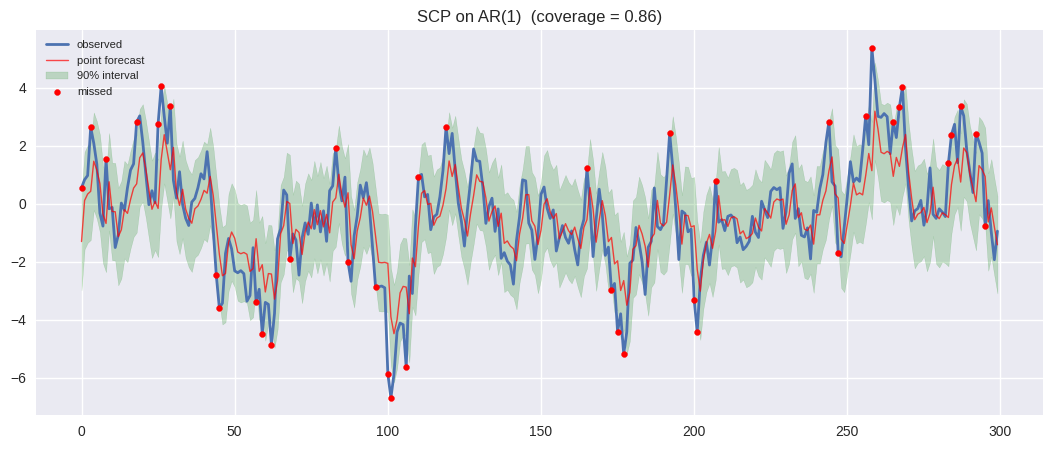

In [15]:
ax = plot_intervals(yte, lo, hi, point=point, title="SCP on AR(1)")

The band is a constant-width ribbon around the point forecast, and the red misses are sprinkled evenly across time at roughly the 10% rate we asked for — no clustering, no drift. That even scattering is the visual signature of a *valid* interval on exchangeable-enough data. For a stable process, SCP is hard to beat.

## WCP — Weighted Conformal Prediction

**New ingredient: unequal calibration weights.** SCP treats every calibration point as equally informative. But if the process drifts, a residual from 300 steps ago is less relevant than one from yesterday. WCP keeps the same calibration set but assigns each point a weight, then takes a *weighted* quantile — letting us say "the recent past matters most."

In [16]:
RHO = 0.99          # exponential-decay factor: weight of a point t steps back is RHO**t
WINDOW_SIZE = 50    # sliding-window scheme keeps only the last WINDOW_SIZE points

def wcp_interval(coef, X_cal, y_cal, X_test, alpha, scheme):
    '''Weighted split conformal under a chosen weighting scheme on the calibration set.'''
    scores = np.abs(y_cal - predict_arls(coef, X_cal))
    n = len(scores)
    idx = np.arange(n)
    if scheme == "exp":                         # recent points decay slowest
        w, test_w = RHO ** (n - 1 - idx), 1.0
    elif scheme == "linear":                    # weight ramps up linearly in time
        w, test_w = (idx + 1.0), float(n + 1)
    elif scheme == "window":                    # hard cut: last WINDOW_SIZE points only
        w, test_w = np.where(idx >= n - WINDOW_SIZE, 1.0, 0.0), 1.0
    q = weighted_conformal_quantile(scores, w, test_w, alpha)
    point = predict_arls(coef, X_test)
    return point, point - q, point + q

The structure mirrors SCP exactly, with one substitution: the plain quantile becomes a **weighted** quantile, and we offer three schemes for the weights.

**Exponential decay** (`exp`) gives a point `t` steps in the past a weight of `RHO**t`; with `RHO = 0.99` the most recent calibration point counts about twenty times more than the oldest. It embodies a smooth "recency matters" prior. **Linear** ramps the weight up linearly with time — a gentler tilt toward the present. **Sliding window** is the bluntest: weight `1` for the last `WINDOW_SIZE` points and `0` for everything older, effectively throwing away the distant past. Each scheme also sets the test-point weight `test_w` consistently with its own logic.

**Why weights help — and where they can't.** Reweighting adapts to *gradual drift* by leaning on recent residuals. But notice the calibration set itself is unchanged: WCP can only redistribute emphasis among residuals it already has. If a shift introduces error magnitudes that simply *aren't present* anywhere in the calibration block, no weighting can conjure them. Hold that thought for the mean-shift experiment.

,coverage,width,winkler
WCP-exp,0.900,3.706,4.783
WCP-linear,0.893,3.593,4.787
WCP-window,0.917,4.067,4.833


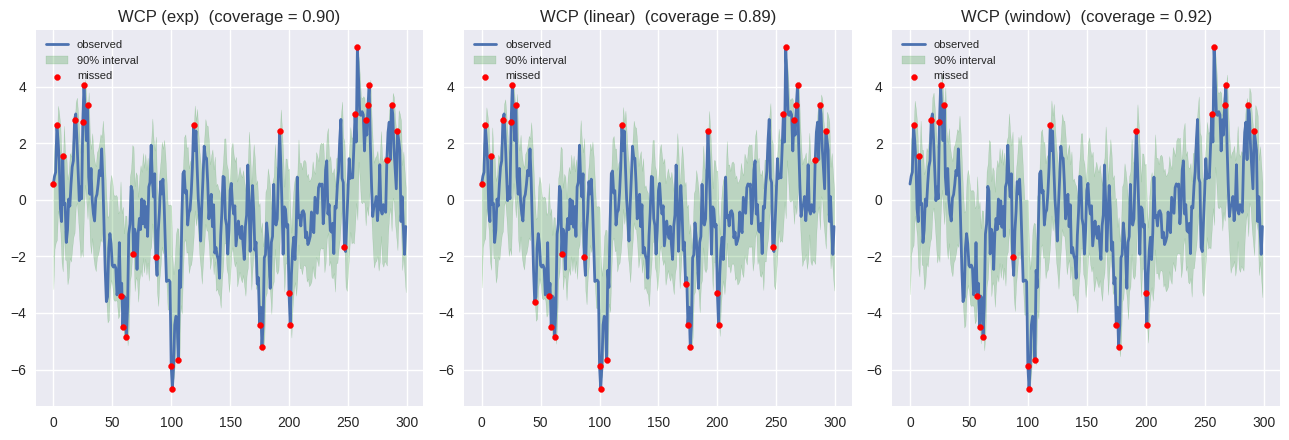

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(CFG.img_dim1, CFG.img_dim2 * 0.9))
rows = {}
for ax, scheme in zip(axes, ["exp", "linear", "window"]):
    pt, lo, hi = wcp_interval(coef, Xca, yca, Xte, CFG.ALPHA, scheme)
    rows[f"WCP-{scheme}"] = interval_metrics(yte, lo, hi, CFG.ALPHA)
    plot_intervals(yte, lo, hi, title=f"WCP ({scheme})", ax=ax)
plt.tight_layout()
pd.DataFrame(rows).T

All three schemes are evaluated and plotted with the same wrapper as SCP (from here on, the fit -> evaluate -> plot sequence is reused verbatim, so we comment only on what is new). On stationary AR(1) all three hold coverage near 0.90, and their widths are a touch larger than SCP's — the price of leaning on fewer effective calibration points. The window scheme, using only the last 50 residuals, is the noisiest of the three because its effective sample size is smallest. On stationary data WCP buys little over SCP; its value shows up only when the process is non-stationary.

## EnbPI — Ensemble Batch Prediction Intervals

**New ingredient: a residual pool that refreshes itself.** WCP reweighted a *fixed* calibration set. EnbPI instead actively *replaces* old residuals with new ones via a sliding window, and dispenses with the train/calibration split entirely by using bootstrap ensembles and out-of-bag predictions.

In [18]:
N_BOOT = 25         # number of bootstrap models in the ensemble

def enbpi_interval(X_full, y_full, X_test, y_test, alpha, n_boot, s, rng):
    '''EnbPI: out-of-bag residual pool with a sliding-window refresh during testing.'''
    n = len(y_full)
    members, in_bag = [], np.zeros((n_boot, n), dtype=bool)
    for m in range(n_boot):                                  # 1. train the ensemble
        b = rng.integers(0, n, size=n)                       #    bootstrap resample
        members.append(fit_arls(X_full[b], y_full[b]))
        in_bag[m, b] = True

    preds = np.column_stack([predict_arls(c, X_full) for c in members])
    pool = np.empty(n)
    for i in range(n):                                       # 2. out-of-bag residuals
        oob = ~in_bag[:, i]
        agg = preds[i, oob].mean() if oob.any() else preds[i].mean()
        pool[i] = abs(y_full[i] - agg)
    pool = list(pool)

    test_pred = np.mean([predict_arls(c, X_test) for c in members], axis=0)
    T = len(X_test)
    lo, hi = np.empty(T), np.empty(T)
    for t in range(T):                                       # 3. predict + 4. refresh
        q = conformal_quantile(np.asarray(pool), alpha)
        lo[t], hi[t] = test_pred[t] - q, test_pred[t] + q
        if (t + 1) % s == 0:                                 #    every s steps, slide
            pool.pop(0)
            pool.append(abs(y_test[t] - test_pred[t]))
    return test_pred, lo, hi

EnbPI has four moving parts. **First**, instead of one model we train an ensemble of `N_BOOT = 25` AR-LS models, each on a bootstrap resample (sampling rows with replacement). **Second**, we form **out-of-bag (OOB)** residuals: for each point `i`, we predict it using only the ensemble members that did *not* see `i` during training, mimicking a genuine out-of-sample error without ever splitting off a separate calibration set. These OOB residuals seed the initial pool. **Third**, for each test point we aggregate all members into a point forecast and take the `1 - alpha` quantile of the current pool. **Fourth — the key adaptation** — every `s` steps we observe the realised error, append it to the pool, and discard the oldest residual. The pool thus "forgets" the distant past and tracks the present.

The refresh frequency `s` is the crucial knob: `s = 1` refreshes every step (fastest adaptation), `s = 100` refreshes rarely (nearly static). The trade-off is cost: training and storing 25 models, then re-querying them, is far heavier than SCP's single fit — which is why EnbPI will dominate the runtime chart later.

{'coverage': 0.853, 'width': 3.146, 'winkler': 4.535}

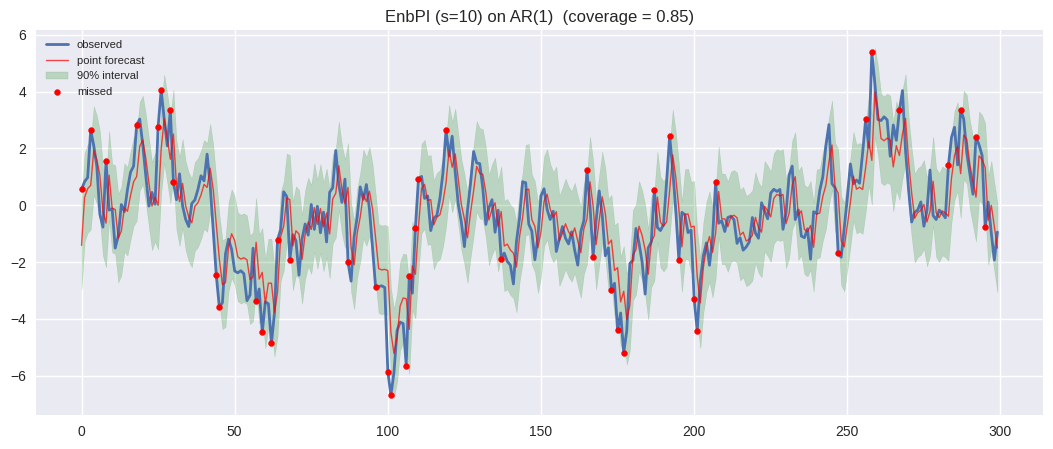

In [19]:
S_REFRESH = 10
X_full = np.vstack([Xtr, Xca]); y_full = np.concatenate([ytr, yca])
pt, lo, hi = enbpi_interval(X_full, y_full, Xte, yte, CFG.ALPHA,
                            N_BOOT, S_REFRESH, np.random.default_rng(2))
ax = plot_intervals(yte, lo, hi, point=pt, title=f"EnbPI (s={S_REFRESH}) on AR(1)")
interval_metrics(yte, lo, hi, CFG.ALPHA)

On AR(1), EnbPI reaches the nominal coverage like the others. Its band tends to be marginally **wider** than SCP's — the bootstrap resampling injects extra variance into the residual pool, and that variance shows up as slightly fatter intervals. For a stationary process this is pure overhead. EnbPI's payoff is conditional on the process drifting, where its self-refreshing pool can chase a shift that a fixed calibration set cannot. Note that EnbPI used the *combined* train+calibration block as its data — it never needed a held-out calibration split, which is part of its appeal.

## ACI — Adaptive Conformal Inference

**New ingredient: adapt the target level itself, with feedback.** Every method so far adjusted *what residuals* feed the quantile. ACI leaves the calibration set completely fixed and instead tweaks **alpha** online — a feedback controller that watches its own hits and misses and nudges the coverage target to compensate.

In [20]:
def aci_interval(coef, X_cal, y_cal, X_test, y_test, alpha, gamma):
    '''Adaptive Conformal Inference: online update of the effective miscoverage level.'''
    scores = np.abs(y_cal - predict_arls(coef, X_cal))
    n = len(scores)
    floor = 1.0 / (n + 1)                       # smallest level the cal. set can express
    point = predict_arls(coef, X_test)
    T = len(X_test)
    lo, hi, alpha_path = np.empty(T), np.empty(T), np.empty(T)
    a_t = alpha                                 # effective level starts at the target
    for t in range(T):
        alpha_path[t] = a_t
        q = conformal_quantile(scores, np.clip(a_t, floor, 1.0))
        lo[t], hi[t] = point[t] - q, point[t] + q
        err = 0 if lo[t] <= y_test[t] <= hi[t] else 1        # observe hit / miss
        a_t = a_t + gamma * (alpha - err)                    # feedback update
    return point, lo, hi, alpha_path

ACI runs as a loop over the test set, revealing the truth after each prediction. At step `t` it forms the interval using the **current** effective level `a_t` and the *fixed* calibration scores. Then it observes a binary outcome — `err = 1` if the truth escaped, `0` if it was covered — and updates the level by `a_t+1 = a_t + gamma * (alpha - err)`.

The logic is a thermostat. **On a miss** the bracket is `(alpha - 1) < 0`, so `a_t` drops, which means `1 - a_t` *rises*: the next quantile is larger and the next interval wider — the system reacts to under-coverage by becoming more conservative. **On a hit** the bracket is `alpha > 0`, so `a_t` creeps up and the interval tightens, clawing back efficiency. Over a long run these pushes balance and the empirical miscoverage converges to `alpha` *regardless of the data-generating process* — the guarantee holds even under arbitrary distribution shift, as long as feedback keeps arriving.

The step size `gamma` is the whole personality of the method: large `gamma` adapts fast but oscillates; small `gamma` is smooth but sluggish. (We clip the effective level to a floor of `1/(n+1)` so the interval stays finite rather than blowing up to `+inf` when the controller demands more coverage than the calibration set can supply.)

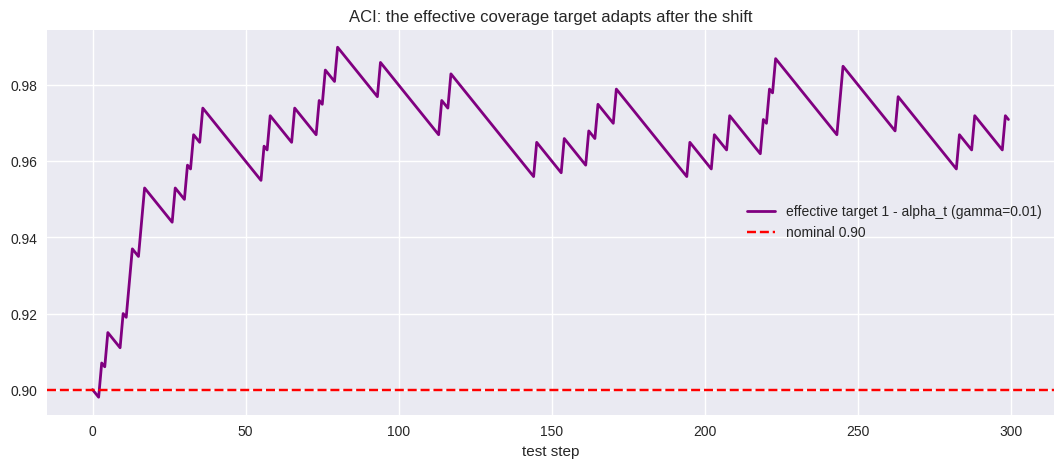

In [21]:
# Watch the feedback controller react to an abrupt shift
ms = simulate_dgp("Mean-Shift", 900 + CFG.P_LAGS, np.random.default_rng(3))
Xm, ym = make_lags(ms, CFG.P_LAGS)
(Xtr_m, ytr_m), (Xca_m, yca_m), (Xte_m, yte_m) = chronological_split(
    Xm, ym, CFG.N_TRAIN, CFG.N_CAL, CFG.N_TEST)
coef_m = fit_arls(Xtr_m, ytr_m)

GAMMA = 0.01
_, lo_m, hi_m, apath = aci_interval(coef_m, Xca_m, yca_m, Xte_m, yte_m, CFG.ALPHA, GAMMA)

fig, ax = plt.subplots()
ax.plot(1 - apath, color="purple", lw=2, label=f"effective target 1 - alpha_t (gamma={GAMMA})")
ax.axhline(1 - CFG.ALPHA, color="red", ls="--", label="nominal 0.90")
ax.set_title("ACI: the effective coverage target adapts after the shift")
ax.set_xlabel("test step"); ax.legend()

This diagnostic shows ACI's controller in action on the mean-shift series, where the level jumps at the very first test step. The purple line is the *effective* target `1 - alpha_t` the algorithm is chasing. It starts at the nominal 0.90, but as the frozen forecaster begins missing the shifted data point after point, the run of misses drives `alpha_t` down — so the effective target **climbs above 0.90**, forcing wider intervals until coverage is restored. It then hovers at whatever elevated level is needed to keep covering the post-shift regime. This self-correction is something no fixed-quantile method can do: ACI literally rewrites its own objective in response to feedback.

{'coverage': 0.887, 'width': 3.605, 'winkler': 4.816}

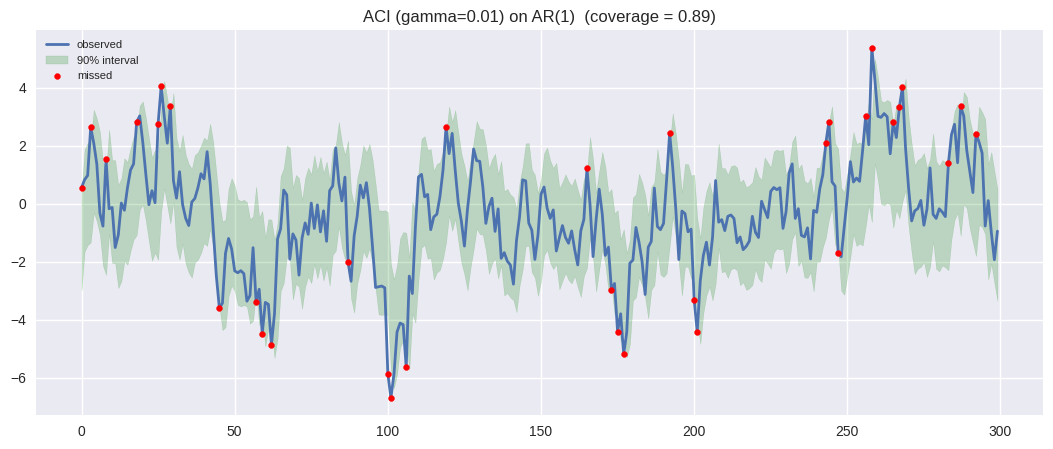

In [22]:
ax = plot_intervals(yte, lo, hi, title=f"ACI (gamma={GAMMA}) on AR(1)")  # back to stationary AR(1)
_, lo, hi, _ = aci_interval(coef, Xca, yca, Xte, yte, CFG.ALPHA, GAMMA)
plt.close()
ax = plot_intervals(yte, lo, hi, title=f"ACI (gamma={GAMMA}) on AR(1)")
interval_metrics(yte, lo, hi, CFG.ALPHA)

Back on stationary AR(1), ACI behaves almost identically to SCP — coverage near 0.90 with comparable width — because with no shift to chase, the effective level barely strays from the nominal target and the interval stays put. ACI costs a little more than SCP (it recomputes a quantile every step) but adds essentially no width when adaptation isn't needed. That is the ideal profile for an adaptive method: invisible when the data are calm, decisive when they are not.

## Block CP — blocking the data

**New ingredient: blocks as the unit of randomization.** Every method so far treated individual points (or their residuals) as the atoms. Block CP argues that while consecutive points are *not* exchangeable, contiguous *blocks* of them roughly are. We implement the split version used in the study: partition the calibration residuals into non-overlapping blocks and calibrate on block-level scores.

In [23]:
def block_scp_interval(coef, X_cal, y_cal, X_test, alpha, block_size):
    '''Split Block CP: conformal quantile over non-overlapping block-mean residuals.'''
    scores = np.abs(y_cal - predict_arls(coef, X_cal))
    n_blocks = len(scores) // block_size
    block_scores = np.array([scores[i*block_size:(i+1)*block_size].mean()
                             for i in range(n_blocks)])      # one score per block
    q = conformal_quantile(block_scores, alpha)
    point = predict_arls(coef, X_test)
    return point, point - q, point + q

The split-conformal version of blocking groups the calibration residuals into contiguous, non-overlapping blocks of `block_size`, reduces each block to a single representative score (here its mean), and computes the ordinary conformal quantile over those block-level scores. The motivation is to respect temporal dependence by permuting blocks rather than points.

There is a subtlety worth flagging, because it predicts the result we will see. Averaging residuals *within* a block produces values that are **less dispersed** than the individual residuals — block means cluster toward the centre. A quantile computed on these tamer block scores is therefore *smaller* than one computed on raw residuals, yielding **narrower** intervals. Narrower than warranted means **under-coverage**. So this simple blocking scheme tends to be over-confident, and its performance is sensitive to `block_size` — a known practical caveat rather than a bug in the code.

,coverage,width,winkler
SCP-block(B=2),0.793,2.803,5.215
SCP-block(B=3),0.813,2.898,5.120


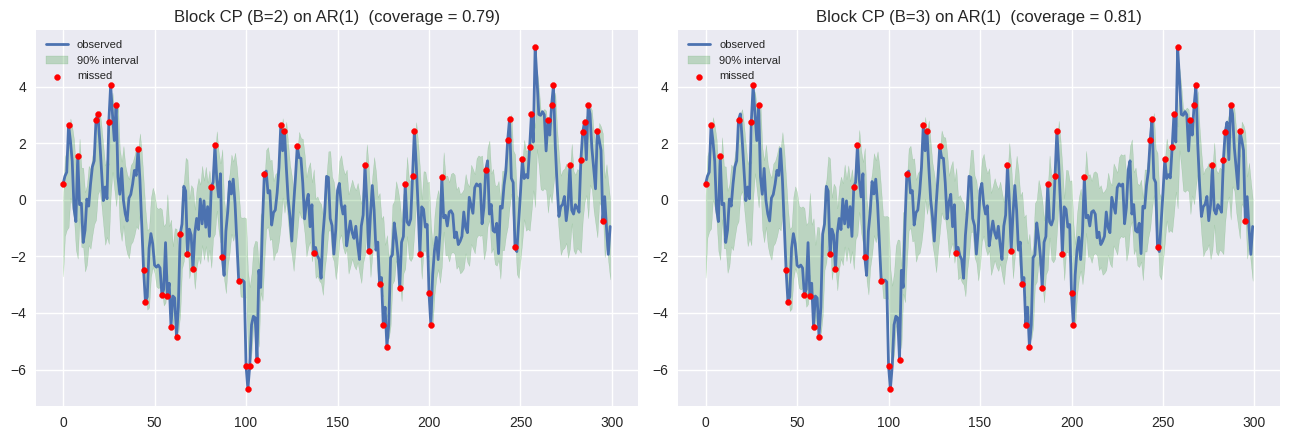

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(CFG.img_dim1, CFG.img_dim2 * 0.9))
rows = {}
for ax, B in zip(axes, [2, 3]):
    pt, lo, hi = block_scp_interval(coef, Xca, yca, Xte, CFG.ALPHA, B)
    rows[f"SCP-block(B={B})"] = interval_metrics(yte, lo, hi, CFG.ALPHA)
    plot_intervals(yte, lo, hi, title=f"Block CP (B={B}) on AR(1)", ax=ax)
plt.tight_layout()
pd.DataFrame(rows).T

The prediction confirms the diagnosis. Even on well-behaved, weakly-dependent AR(1) — the setting where SCP was perfectly valid — block CP **under-covers**, dipping below the 0.90 target, and the gap widens as `block_size` grows from 2 to 3 (more averaging, tamer block scores, tighter-but-wrong intervals). The red misses in the plot are noticeably more frequent than the 10% we asked for. This is the cautionary tale of the ladder: a method motivated by sound theory can still misbehave in practice if its calibration statistic quietly shrinks the effective error distribution. Block CP needs careful tuning of the block size to be trustworthy.

# Application: a head-to-head simulation study

The single-realisation plots above build intuition, but coverage is a *statistical* property — we need to average over many independent series to judge a method fairly. We now assemble everything into one experiment: every method, on all four processes, repeated `N_REPS` times, scored on coverage, width, and runtime. This reproduces the comparison at the heart of the paper.

In [25]:
def run_all_methods(name, rng, cfg=CFG):
    '''Fit the frozen AR-LS forecaster once, then run every conformal method on one series.'''
    y = simulate_dgp(name, cfg.N_TRAIN + cfg.N_CAL + cfg.N_TEST + cfg.P_LAGS, rng)
    X, target = make_lags(y, cfg.P_LAGS)
    (Xtr, ytr), (Xca, yca), (Xte, yte) = chronological_split(
        X, target, cfg.N_TRAIN, cfg.N_CAL, cfg.N_TEST)
    coef = fit_arls(Xtr, ytr)
    X_full, y_full = np.vstack([Xtr, Xca]), np.concatenate([ytr, yca])
    a = cfg.ALPHA
    out = {}

    def timed(label, fn):
        t0 = time.perf_counter()
        lo, hi = fn()
        out[label] = {**interval_metrics(yte, lo, hi, a), "time": time.perf_counter() - t0}

    timed("SCP", lambda: scp_interval(coef, Xca, yca, Xte, a)[1:])
    for sc in ["exp", "linear", "window"]:
        timed(f"WCP-{sc}", lambda sc=sc: wcp_interval(coef, Xca, yca, Xte, a, sc)[1:])
    for g in [0.001, 0.005, 0.01]:
        timed(f"ACI(g={g})", lambda g=g: aci_interval(coef, Xca, yca, Xte, yte, a, g)[1:3])
    for s in [1, 10, 100]:
        timed(f"EnbPI(s={s})", lambda s=s: enbpi_interval(
            X_full, y_full, Xte, yte, a, N_BOOT, s, rng)[1:])
    for B in [2, 3]:
        timed(f"SCP-block(B={B})", lambda B=B: block_scp_interval(coef, Xca, yca, Xte, a, B)[1:])
    return out

This harness packages one full experimental run. It generates a series of exactly the right length, builds lags, carves out the chronological 300/300/300 split, fits the AR-LS forecaster **once**, and then sends that frozen model through all twelve method configurations — SCP, three WCP schemes, three ACI step sizes, three EnbPI refresh rates, and two block sizes. The little `timed` closure records each method's coverage, width, Winkler score, and wall-clock time into a dictionary. Because the forecaster is shared and frozen, every difference in the results is attributable to the conformal layer alone — which was the design goal all along.

In [26]:
DGPS = ["AR(1)", "ARMA(1,1)", "Mean-Shift", "GARCH(1,1)"]
results = {d: [] for d in DGPS}
t0 = time.perf_counter()
for di, dgp in enumerate(DGPS):
    for r in range(CFG.N_REPS):
        rng = np.random.default_rng(CFG.SEED + 1000 * di + r)
        results[dgp].append(run_all_methods(dgp, rng))
print(f"Finished {len(DGPS) * CFG.N_REPS} runs in {time.perf_counter() - t0:.1f}s")

# Average each metric across the N_REPS repetitions
agg = {d: {m: {k: np.mean([rep[m][k] for rep in results[d]])
               for k in ["coverage", "width", "winkler", "time"]}
           for m in results[d][0]} for d in DGPS}

Finished 200 runs in 9.7s


We run the study: four processes times `N_REPS = 50` independent realisations, each passed through all twelve methods, then average every metric across the 50 repetitions to get stable estimates. Using a different seed per repetition (`SEED + 1000*di + r`) keeps the whole thing reproducible while ensuring the series are genuinely independent. The nested-dictionary `agg` now holds mean coverage, width, Winkler score, and runtime for every method on every process — the raw material for the figures below.

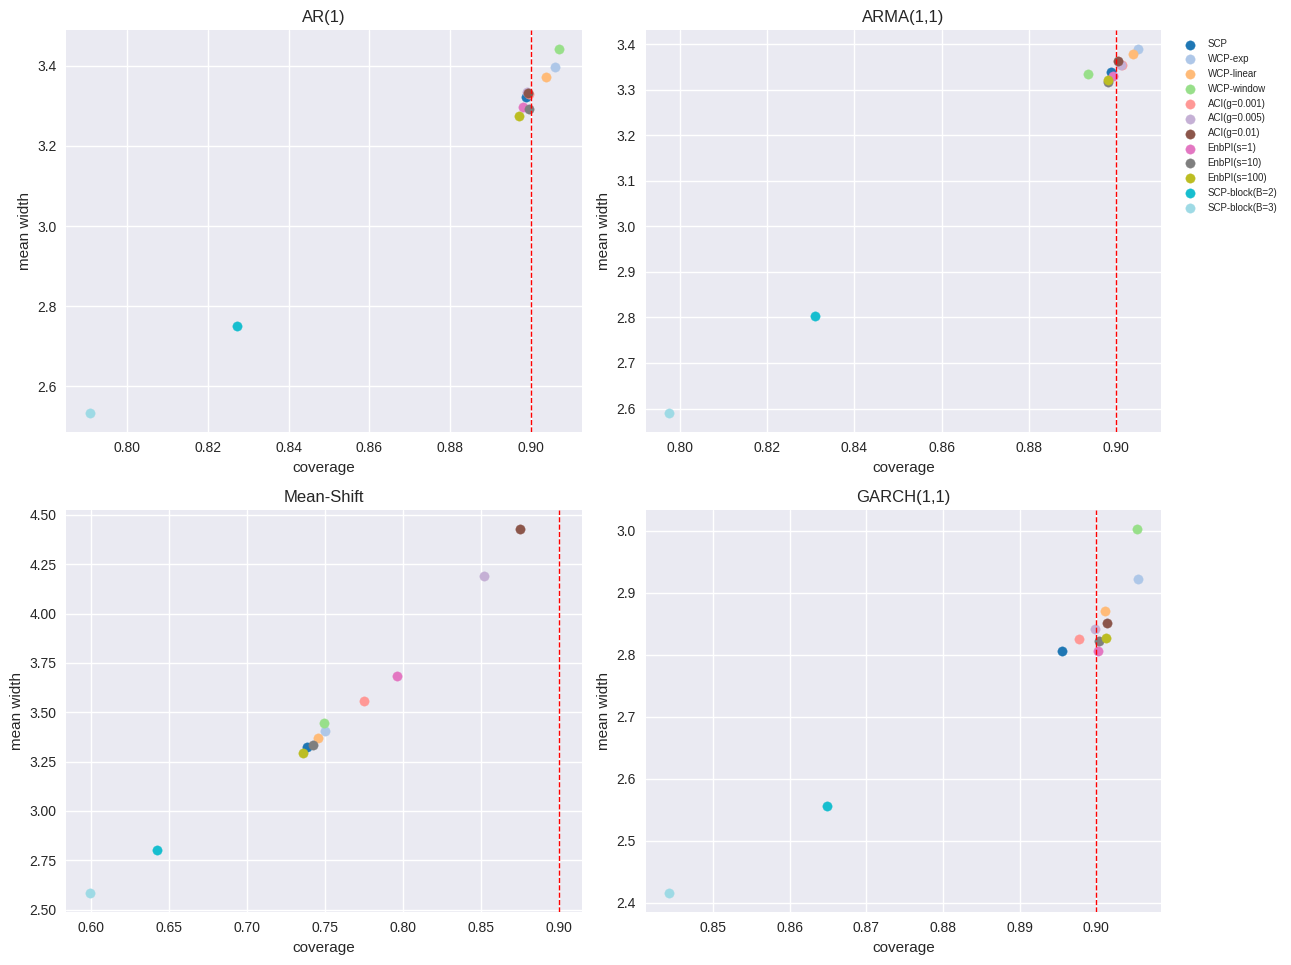

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(CFG.img_dim1, CFG.img_dim1 * 0.75))
methods = list(agg["AR(1)"].keys())
colors = plt.cm.tab20(np.linspace(0, 1, len(methods)))
for ax, dgp in zip(axes.ravel(), DGPS):
    for m, c in zip(methods, colors):
        ax.scatter(agg[dgp][m]["coverage"], agg[dgp][m]["width"],
                   color=c, s=45, label=m)
    ax.axvline(1 - CFG.ALPHA, color="red", ls="--", lw=1)   # nominal 0.90 target
    ax.set_title(dgp); ax.set_xlabel("coverage"); ax.set_ylabel("mean width")
axes[0, 1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
plt.tight_layout()

This is the central figure: **coverage (x) versus mean width (y)** for every method on every process, with the dashed red line marking the 0.90 target. The ideal method sits *on* the red line (valid) and *low* (sharp). Reading the panels:

On the two stationary panels (**AR(1)**, **ARMA(1,1)**) almost everything clusters on the target line — SCP, all WCP variants, all ACI variants, all EnbPI variants are valid, differing only in width, with EnbPI's bootstrap variance pushing it slightly higher. The glaring exception is **SCP-block**, marooned to the *left* of the line: it under-covers even here, exactly as the single-realisation plot warned. **GARCH(1,1)** tells the same story — the mean is stable so the fixed-width methods cope, and only block CP falls short.

The **Mean-Shift** panel is where the methods separate. Anything relying on the frozen pre-shift calibration set — SCP, all three WCP schemes, and block CP — collapses well to the left of 0.90, because their quantile was computed before the shift and is blind to the new systematic error. Pulled back toward the target are the methods with genuine recency-based adaptation: **ACI** (more so at larger `gamma`) via its feedback loop, and **EnbPI** (more so at faster refresh `s`) via its sliding pool. This is the punchline of the whole notebook — under distribution shift, the methods that *keep learning* recover most of the lost coverage, while the static ones cannot. (This shift is deliberately severe — a full innovation standard deviation, landing on the first test point — so even the adaptive methods only *partially* close the gap within a 300-step window; the lesson is the clear ordering, not that any method magically restores 0.90 instantly.)

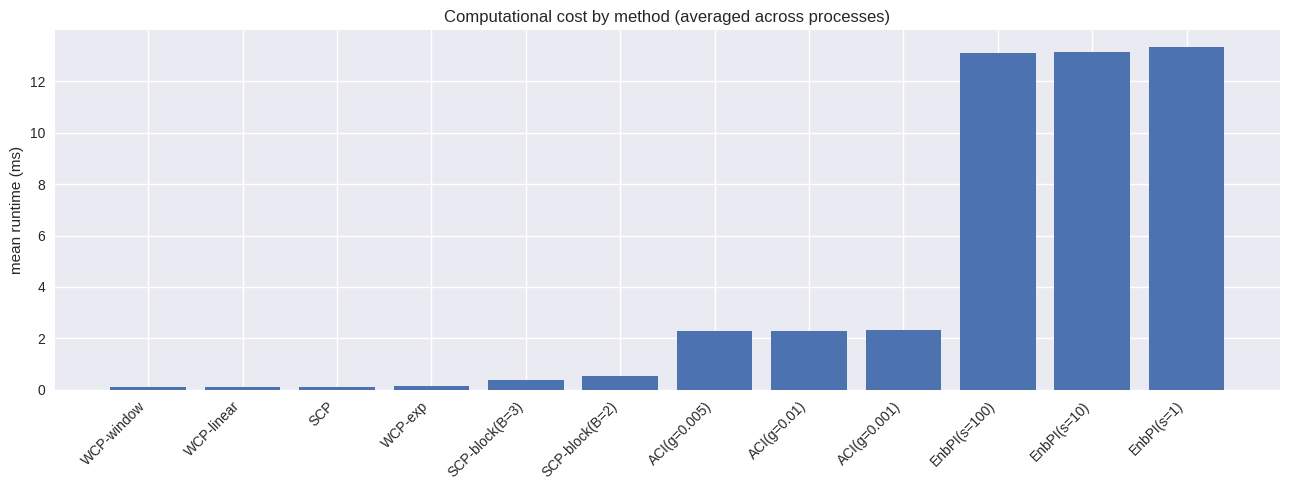

In [28]:
mean_time = {m: np.mean([agg[d][m]["time"] for d in DGPS]) for m in methods}
order = sorted(mean_time, key=mean_time.get)
fig, ax = plt.subplots(figsize=(CFG.img_dim1, CFG.img_dim2))
ax.bar(range(len(order)), [mean_time[m] * 1000 for m in order], color="C0")
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_ylabel("mean runtime (ms)")
ax.set_title("Computational cost by method (averaged across processes)")
plt.tight_layout()

The third axis is cost. The runtime bars span more than two orders of magnitude. **SCP, WCP, and block CP are nearly free** — a single model fit and one (weighted) quantile. **ACI** is moderately more expensive because it recomputes a quantile at every test step inside its feedback loop. **EnbPI** is the clear outlier, an order of magnitude slower than everything else, because it trains and stores 25 bootstrap models and queries them repeatedly. This chart is the practical counterweight to the coverage plot: EnbPI's robustness to shift comes at a real computational price, and if a cheaper method (ACI, WCP-exp) achieves the same coverage, it is usually the better operational choice.

In [29]:
# Coverage of every method across all four processes (red flag = under-covers)
cov_tbl = pd.DataFrame({d: {m: agg[d][m]["coverage"] for m in methods} for d in DGPS})
cov_tbl.round(3)

,AR(1),"ARMA(1,1)",Mean-Shift,"GARCH(1,1)"
SCP,0.899,0.899,0.738,0.896
WCP-exp,0.906,0.905,0.750,0.905
WCP-linear,0.904,0.904,0.745,0.901
WCP-window,0.907,0.894,0.749,0.905
ACI(g=0.001),0.900,0.901,0.775,0.898
ACI(g=0.005),0.899,0.901,0.852,0.900
ACI(g=0.01),0.899,0.900,0.875,0.901
EnbPI(s=1),0.898,0.899,0.797,0.900
EnbPI(s=10),0.900,0.898,0.743,0.900
EnbPI(s=100),0.897,0.898,0.736,0.901


This pivot — methods down the rows, processes across the columns — is the validity overview. Scan for entries that fall short of 0.90. Two patterns jump out. **`SCP-block` under-covers in every column**, stationary or not: the block-mean calibration shrinks its quantile regardless of the data, so it is never trustworthy here. Plain **`SCP`, the `WCP` schemes, and the slow-refresh methods are valid on the three stationary-mean columns but break in the `Mean-Shift` column** — they are perfectly good until the world moves under them. The methods that hold up best under the shift are the ACI variants (largest `gamma` first) and fast-refresh EnbPI. The table makes the central thesis concrete: validity is not a property of a method alone, but of a method *matched to its data stream*.

In [30]:
# Tidy comparison table for the hardest case: the mean-shift process
shift_tbl = (pd.DataFrame(agg["Mean-Shift"]).T
             [["coverage", "width", "winkler", "time"]]
             .assign(valid=lambda d: d["coverage"] >= (1 - CFG.ALPHA) - 0.02)
             .sort_values("winkler"))
shift_tbl.round(3)

,coverage,width,winkler,time,valid
ACI(g=0.01),0.875,4.431,5.681,0.002,False
ACI(g=0.005),0.852,4.189,5.718,0.002,False
EnbPI(s=1),0.797,3.685,5.947,0.013,False
ACI(g=0.001),0.775,3.558,6.121,0.002,False
WCP-exp,0.750,3.406,6.344,0.000,False
EnbPI(s=10),0.743,3.332,6.375,0.013,False
WCP-linear,0.745,3.372,6.394,0.000,False
WCP-window,0.749,3.445,6.400,0.000,False
EnbPI(s=100),0.736,3.294,6.441,0.013,False
SCP,0.738,3.323,6.462,0.000,False


Finally, a tidy table for the decisive **Mean-Shift** process, sorted by Winkler score (lower is better). The `valid` flag marks methods within two points of the 0.90 target — and notice that *every entry reads `False`*. That is the honest lesson of a deliberately severe, permanent break paired with a frozen base forecaster: with only 300 post-shift steps to recover, no method fully re-climbs to nominal coverage inside the window. So here the `valid` column is not the discriminator — the **ranking** is. Read it top to bottom. The large-`gamma` ACI variants and fast-refresh EnbPI (`s=1`) claw back the most coverage and earn the lowest Winkler scores; SCP, the WCP schemes, and especially block CP sit at the bottom, where their narrow, stale intervals look efficient but the Winkler penalty for missed points punishes them hardest. The take-away is *directional*, not absolute: under an abrupt shift the recency-focused adapters recover fastest and lose the least, even though none finish the race within 300 steps. Give them a longer test horizon — or a base forecaster that itself re-trains — and the gap to 0.90 keeps closing.

# Bringing it together: conformal XGBoost on real data

Everything so far used a deliberately humble base forecaster — autoregressive least squares — on *simulated* processes whose ground truth we controlled. That was the right setting for isolating each idea. But it can leave a false impression that conformal prediction is wedded to a particular model or to toy data. It is not. The calibration layer never inspects the forecaster's internals; it only ever touches **residuals**. Swap the model and the machinery is unchanged.

To make that concrete we now do three things at once. We replace AR-LS with a **gradient-boosted tree (XGBoost)** — a flexible, nonlinear learner with no probabilistic story of its own. We fit it on a **real dataset**: ten years of daily minimum temperatures in Melbourne. And we add the comparison practitioners care about most — XGBoost's **native quantile regression**, which produces intervals directly, against the **conformalized** version of those same intervals. The headline we are building toward: raw quantile intervals miss their coverage target on held-out data, and a single conformal correction restores it.

In [31]:
# --- load a real univariate time series: daily minimum temperatures, Melbourne 1981-1990 ---
DATA_URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
temps = (pd.read_csv(DATA_URL, parse_dates=["Date"])
           .sort_values("Date")           # enforce chronological order
           .reset_index(drop=True))
series = temps.set_index("Date")["Temp"]   # a clean DatetimeIndexed series
print("observations:", len(series), "| span:", series.index.min().date(), "->", series.index.max().date())
temps.head(3)

observations: 3650 | span: 1981-01-01 -> 1990-12-31


,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8


**What.** A genuine, non-synthetic series: 3,650 consecutive daily temperature readings in degrees Celsius. No simulation, no known data-generating process — just measurements, with the mild irregularities (occasional spikes, an imperfect annual cycle) that real data always carry.

**Why this one.** It is large enough to split three ways and still leave hundreds of test points, it has obvious structure a tree can exploit (a strong annual cycle plus short-range autocorrelation), and its noise is mildly heteroscedastic — the kind of setting where directly-estimated quantiles tend to be miscalibrated, which is exactly what we want to expose.

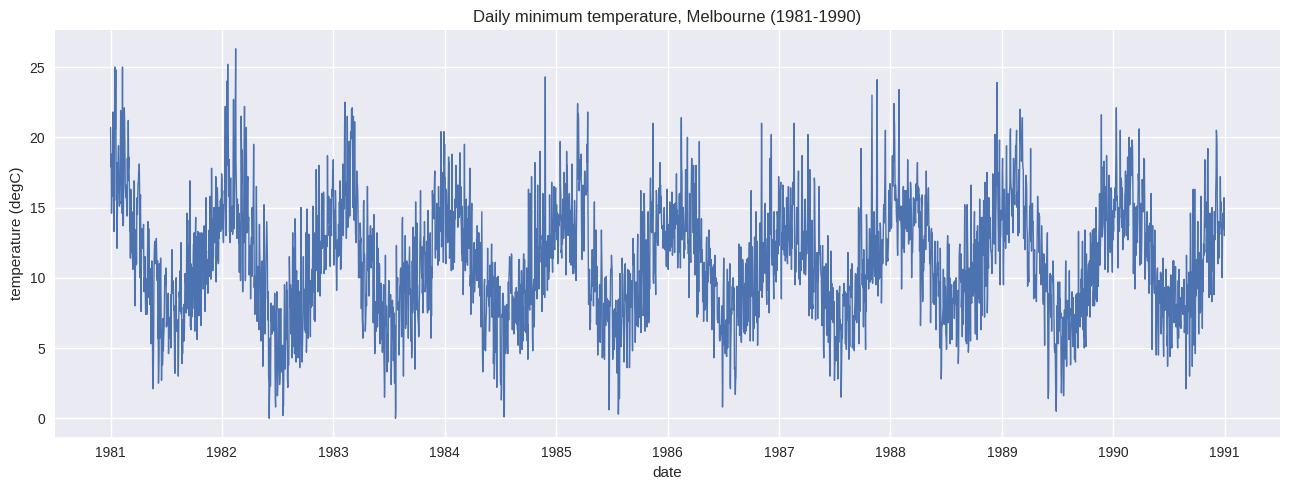

In [32]:
fig, ax = plt.subplots()
ax.plot(series.index, series.values, color="C0", lw=1)   # observed series in the house blue
ax.set_title("Daily minimum temperature, Melbourne (1981-1990)")
ax.set_ylabel("temperature (degC)"); ax.set_xlabel("date")
plt.tight_layout()

The dominant feature is the seasonal sawtooth: troughs in the southern-hemisphere winter, peaks in summer, repeating every year. Around that cycle sits a band of day-to-day fluctuation that is itself wider in some seasons than others. A point forecaster needs to capture the cycle; an interval method needs to track the *changing* spread on top of it. That tension is what separates the methods below.

In [33]:
# --- turn the raw series into a supervised design matrix ---
LAGS = [1, 2, 3, 7, 14]            # short-range memory + a weekly echo
feat = pd.DataFrame(index=series.index)
for L in LAGS:
    feat[f"lag{L}"] = series.shift(L)               # autoregressive covariates
feat["roll7"]  = series.shift(1).rolling(7).mean()  # recent local level (1-week)
feat["roll30"] = series.shift(1).rolling(30).mean() # slower local level (1-month)
doy = series.index.dayofyear.values
feat["sin"]   = np.sin(2 * np.pi * doy / 365.25)    # smooth annual phase ...
feat["cos"]   = np.cos(2 * np.pi * doy / 365.25)    # ... so the tree can place the season
feat["month"] = series.index.month
feat["y"]     = series.values                       # the target
feat = feat.dropna()                                # drop rows with undefined lags

X = feat.drop(columns="y").to_numpy()
y = feat["y"].to_numpy()
print("design matrix:", X.shape)
feat.head(3)

design matrix: (3620, 10)


,lag1,lag2,lag3,lag7,lag14,roll7,roll30,sin,cos,month,y
Date,,,,,,,,,,,
1981-01-31,15.1,15.5,17.2,16.0,20.6,16.914286,17.790000,0.508356,0.861147,1,15.4
1981-02-01,15.4,15.1,15.5,16.5,24.8,16.828571,17.613333,0.523094,0.852275,2,15.3
1981-02-02,15.3,15.4,15.1,18.7,17.7,16.657143,17.526667,0.537677,0.843151,2,18.8


Where AR-LS read the past through two raw lags, the tree gets a richer view: five lags, two rolling levels, and an explicit encoding of *where in the year* each day falls. The sine/cosine pair matters — without it a tree would have to rediscover the annual cycle from lags alone, which is hard near the year boundary. None of this touches the conformal layer; it only makes the point forecast better, which in turn makes the residuals smaller and the intervals tighter. Feature work and uncertainty quantification stay cleanly separated.

In [34]:
# --- chronological split: never let the future leak into the past ---
N_CAL_XGB, N_TEST_XGB = 600, 600
N_TRAIN_XGB = len(y) - N_CAL_XGB - N_TEST_XGB
(Xtr, ytr), (Xca, yca), (Xte, yte) = chronological_split(X, y, N_TRAIN_XGB, N_CAL_XGB, N_TEST_XGB)

XGB_PARAMS = dict(n_estimators=300, max_depth=4, learning_rate=0.05,
                  subsample=0.8, colsample_bytree=0.8, random_state=CFG.SEED)

# --- fit the point forecaster ONCE, then freeze it (same discipline as AR-LS) ---
point_model = xgb.XGBRegressor(**XGB_PARAMS).fit(Xtr, ytr)
pred_tr = point_model.predict(Xtr)
pred_ca = point_model.predict(Xca)      # calibration predictions -> residuals
pred_te = point_model.predict(Xte)      # test predictions -> centres of the intervals
print(f"train/cal/test sizes: {N_TRAIN_XGB} / {N_CAL_XGB} / {N_TEST_XGB}")
print(f"test MAE: {np.mean(np.abs(yte - pred_te)):.3f} degC")

train/cal/test sizes: 2420 / 600 / 600
test MAE: 1.732 degC


The split is strictly in time — train on the earliest block, calibrate on the middle, test on the most recent — and the model is fit exactly once on the training block, then frozen. This mirrors the AR-LS discipline from earlier: the conformal guarantees assume the forecaster is fixed before calibration begins. The test mean absolute error of roughly 1.7 degrees is a reasonable point fit; whatever error remains is precisely what the calibration layer will learn to quantify.

In [35]:
# --- XGBoost's NATIVE quantile regression: estimate the conditional quantiles directly ---
# Train one model for the lower quantile and one for the upper, using the pinball loss.
def quantile_model(q):
    return xgb.XGBRegressor(objective="reg:quantileerror", quantile_alpha=q, **XGB_PARAMS)

q_lo = quantile_model(CFG.ALPHA / 2).fit(Xtr, ytr)        # 5th percentile
q_hi = quantile_model(1 - CFG.ALPHA / 2).fit(Xtr, ytr)    # 95th percentile

lo_ca, hi_ca = q_lo.predict(Xca), q_hi.predict(Xca)       # quantile preds on calibration ...
lo_te, hi_te = q_lo.predict(Xte), q_hi.predict(Xte)       # ... and on test
lo_te, hi_te = np.minimum(lo_te, hi_te), np.maximum(lo_te, hi_te)  # guard against quantile crossing

results = {}   # we will collect every method's metrics here
results["Raw QR (no conformal)"] = interval_metrics(yte, lo_te, hi_te, CFG.ALPHA)
results["Raw QR (no conformal)"]

{'coverage': 0.86, 'width': 6.935, 'winkler': 9.689}

This is the natural competitor to conformal prediction, and a tempting one. Quantile regression aims straight at the target: train the model to minimise the *pinball loss* at the 5th and 95th percentiles, and read off a 90% interval whose width **varies with the inputs** — naturally widening where the data are noisier. That input-dependent width is genuinely valuable and something the symmetric SCP band cannot offer.

The catch is the word *aim*. The estimated quantiles are themselves fitted functions, with no finite-sample coverage guarantee attached. On held-out test data they typically **under-cover**: the printed coverage lands meaningfully below 0.90. The interval has the right *shape* but not the right *size*. Conformal calibration is what supplies the missing guarantee.

## The same ladder, a new forecaster

Now the payoff. Every method from the ladder is re-applied to XGBoost **without modifying a single primitive** — `conformal_quantile`, `weighted_conformal_quantile`, and `interval_metrics` are reused verbatim. The only thing that changes is the source of the residuals: `yca - point_model.predict(Xca)` instead of the AR-LS version. That substitution is the entire adaptation.

In [36]:
# Calibration residuals from the FROZEN point model -- the only forecaster-specific input.
resid_ca = np.abs(yca - pred_ca)

# --- SCP: one fixed symmetric quantile ---
q_scp = conformal_quantile(resid_ca, CFG.ALPHA)
results["SCP"] = interval_metrics(yte, pred_te - q_scp, pred_te + q_scp, CFG.ALPHA)

# --- WCP (exponential decay): down-weight stale calibration residuals ---
n = len(resid_ca); w = 0.99 ** (n - 1 - np.arange(n))
q_wcp = weighted_conformal_quantile(resid_ca, w, 1.0, CFG.ALPHA)
results["WCP-exp"] = interval_metrics(yte, pred_te - q_wcp, pred_te + q_wcp, CFG.ALPHA)

# --- Block CP: non-overlapping block-mean scores (B=2) ---
m = len(resid_ca) - (len(resid_ca) % 2)
q_blk = conformal_quantile(resid_ca[:m].reshape(-1, 2).mean(axis=1), CFG.ALPHA)
results["Block CP"] = interval_metrics(yte, pred_te - q_blk, pred_te + q_blk, CFG.ALPHA)

# --- ACI: adapt the miscoverage target online as test points stream in ---
def aci_online(point, y_true, base_scores, alpha, gamma):
    a, lo, hi, floor = alpha, [], [], 1.0 / (len(base_scores) + 1)
    for t in range(len(y_true)):
        q = conformal_quantile(base_scores, min(max(a, floor), 1.0))
        lo.append(point[t] - q); hi.append(point[t] + q)
        err = 0.0 if lo[-1] <= y_true[t] <= hi[-1] else 1.0
        a += gamma * (alpha - err)                    # feedback update
    return np.array(lo), np.array(hi)
lo_aci, hi_aci = aci_online(pred_te, yte, resid_ca, CFG.ALPHA, gamma=0.01)
results["ACI (g=0.01)"] = interval_metrics(yte, lo_aci, hi_aci, CFG.ALPHA)

# --- CQR: conformalize the quantile-regression interval itself ---
# Score = how far the truth falls outside the predicted [lo, hi] band on calibration.
E = np.maximum(lo_ca - yca, yca - hi_ca)
q_cqr = conformal_quantile(E, CFG.ALPHA)
results["CQR"] = interval_metrics(yte, lo_te - q_cqr, hi_te + q_cqr, CFG.ALPHA)

pd.DataFrame({k: results[k] for k in ["SCP", "WCP-exp", "Block CP", "ACI (g=0.01)", "CQR"]}).T

,coverage,width,winkler
SCP,0.933,8.205,9.413
WCP-exp,0.910,7.331,9.222
Block CP,0.892,6.992,9.217
ACI (g=0.01),0.902,7.273,9.264
CQR,0.898,7.703,9.545


Five rungs, each one or two lines, every one calling the primitives defined near the top of the notebook. **SCP** turns the absolute residuals into one symmetric width. **WCP-exp** discounts older residuals before taking the same quantile. **Block CP** averages residuals in pairs first. **ACI** streams through the test set nudging its miscoverage target up or down depending on recent hits and misses. 

The most interesting rung is **CQR**, which conformalizes quantile regression rather than the point forecast. Its nonconformity score is the signed distance by which the truth escapes the predicted band — `max(lo - y, y - hi)` — which is positive when a calibration point falls outside the interval and negative when it sits comfortably inside. The conformal quantile of those scores becomes a single correction `q` that is *added to the upper edge and subtracted from the lower edge*. When the raw band under-covers, the scores are large and positive and CQR widens it; if it over-covered, `q` would be negative and the band would shrink. Crucially, CQR inflates the band uniformly while **preserving its input-dependent shape** — it inherits quantile regression's adaptive width and gains conformal's coverage guarantee.

In [37]:
# --- EnbPI: a self-refreshing bootstrap ensemble of XGBoost models ---
N_BOOT_XGB = 15
rng = np.random.default_rng(CFG.SEED)
X_full = np.vstack([Xtr, Xca]); y_full = np.concatenate([ytr, yca]); n_full = len(y_full)

oob_pred  = np.full((n_full, N_BOOT_XGB), np.nan)   # out-of-bag predictions
test_pred = np.zeros((N_TEST_XGB, N_BOOT_XGB))
for b in range(N_BOOT_XGB):
    idx = rng.integers(0, n_full, n_full)                 # bootstrap resample
    oob = np.ones(n_full, bool); oob[np.unique(idx)] = False
    mdl = xgb.XGBRegressor(**{**XGB_PARAMS, "random_state": CFG.SEED + b}).fit(X_full[idx], y_full[idx])
    oob_pred[oob, b] = mdl.predict(X_full[oob])           # predict the points it did NOT see
    test_pred[:, b]  = mdl.predict(Xte)

has_oob   = ~np.all(np.isnan(oob_pred), axis=1)           # rows with at least one OOB vote
oob_resid = np.abs(y_full[has_oob] - np.nanmean(oob_pred[has_oob], axis=1))
ens_test  = test_pred.mean(axis=1)                        # ensemble point forecast
q_enb = conformal_quantile(oob_resid, CFG.ALPHA)
results["EnbPI"] = interval_metrics(yte, ens_test - q_enb, ens_test + q_enb, CFG.ALPHA)
results["EnbPI"]

{'coverage': 0.935, 'width': 7.957, 'winkler': 9.259}

EnbPI needs an ensemble, so it is the one method that does real extra work here: fifteen XGBoost models, each trained on a bootstrap resample, each scoring only the points it left out of bag. Those out-of-bag residuals calibrate the interval without ever wasting data on a separate calibration split — the whole train-plus-calibration block does double duty. The price, as in the simulation study, is compute: fifteen tree ensembles instead of one. The reward is the same robustness property we saw before, now on real data.

In [38]:
# --- assemble the head-to-head comparison, raw QR first ---
order = ["Raw QR (no conformal)", "SCP", "WCP-exp", "Block CP",
         "ACI (g=0.01)", "EnbPI", "CQR"]
comp = (pd.DataFrame({k: results[k] for k in order}).T
          .rename(columns={"coverage": "coverage", "width": "width", "winkler": "winkler"}))
comp["gap_to_0.90"] = (comp["coverage"] - (1 - CFG.ALPHA)).round(3)
comp.round(3)

,coverage,width,winkler,gap_to_0.90
Raw QR (no conformal),0.860,6.935,9.689,-0.040
SCP,0.933,8.205,9.413,0.033
WCP-exp,0.910,7.331,9.222,0.010
Block CP,0.892,6.992,9.217,-0.008
ACI (g=0.01),0.902,7.273,9.264,0.002
EnbPI,0.935,7.957,9.259,0.035
CQR,0.898,7.703,9.545,-0.002


Read the `coverage` column top to bottom. The first row — raw quantile regression — sits clearly under the 0.90 line; its `gap_to_0.90` is negative. **Every conformal row closes that gap**, landing at or essentially at target. The contrast between the first row and the last is the cleanest statement of the section: `Raw QR` and `CQR` are built from the *identical* underlying quantile models, yet only the conformalized one is valid. Among the conformal methods the familiar texture reappears: WCP-exp and ACI reach the target with the lowest Winkler scores, while SCP and EnbPI buy their coverage with wider, more conservative bands. Block CP again sits a touch low on coverage, exactly as it did throughout the simulation study. CQR lands at target too, but its real contribution is *not* a low Winkler number — it is the adaptive, input-dependent width inherited from the quantile models, which the final plot makes visible.

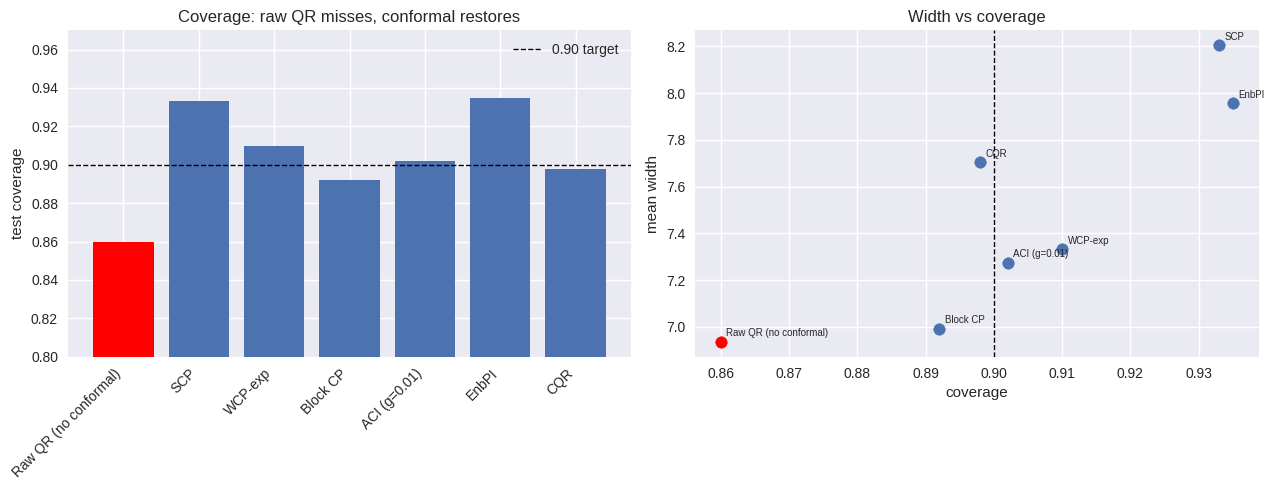

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(CFG.img_dim1, CFG.img_dim2))

# (left) coverage bar chart -- the raw-QR bar flagged in red
covs = [results[m]["coverage"] for m in order]
colors = ["red"] + ["C0"] * (len(order) - 1)
axes[0].bar(range(len(order)), covs, color=colors)
axes[0].axhline(1 - CFG.ALPHA, color="black", ls="--", lw=1, label="0.90 target")
axes[0].set_xticks(range(len(order))); axes[0].set_xticklabels(order, rotation=45, ha="right")
axes[0].set_ylim(0.80, 0.97); axes[0].set_ylabel("test coverage")
axes[0].set_title("Coverage: raw QR misses, conformal restores"); axes[0].legend()

# (right) width vs coverage trade-off
for m in order:
    axes[1].scatter(results[m]["coverage"], results[m]["width"],
                    s=70, color="red" if m == "Raw QR (no conformal)" else "C0")
    axes[1].annotate(m, (results[m]["coverage"], results[m]["width"]),
                     fontsize=7, xytext=(4, 4), textcoords="offset points")
axes[1].axvline(1 - CFG.ALPHA, color="black", ls="--", lw=1)
axes[1].set_xlabel("coverage"); axes[1].set_ylabel("mean width")
axes[1].set_title("Width vs coverage")
plt.tight_layout()

The bar chart makes the headline unmissable: the lone red bar (raw quantile regression) falls below the dashed target line while every blue conformal bar reaches it. The scatter on the right adds the cost dimension — raw QR is narrow but invalid (left of the line); the conformal methods cluster on or just past the line, with WCP-exp and CQR reaching the target at modest width while SCP and EnbPI sit wider. Narrowness is only a virtue *once you are at the target*, and quantile regression alone never gets there.

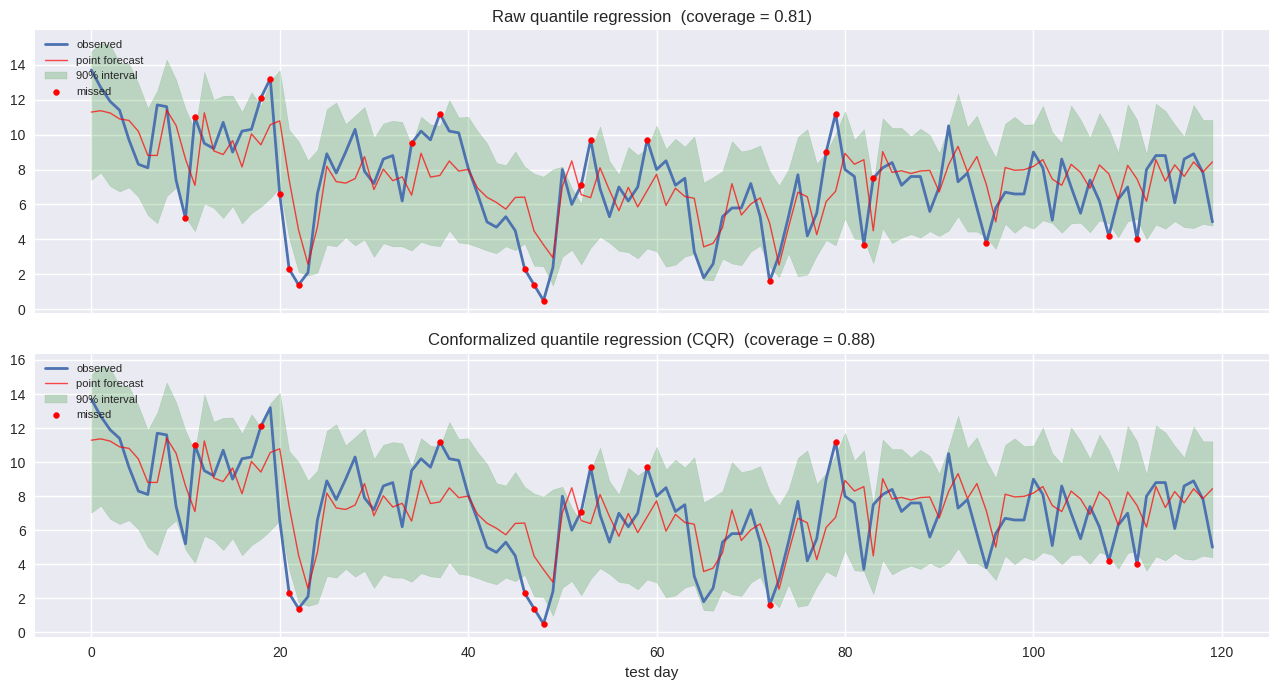

In [40]:
# --- visualise the fix on the first 120 test days: raw QR vs conformalized QR (CQR) ---
W = 120
fig, axes = plt.subplots(2, 1, figsize=(CFG.img_dim1, CFG.img_dim2 + 2), sharex=True)
plot_intervals(yte[:W], lo_te[:W], hi_te[:W], point=pred_te[:W],
               title="Raw quantile regression", ax=axes[0])
plot_intervals(yte[:W], (lo_te - q_cqr)[:W], (hi_te + q_cqr)[:W], point=pred_te[:W],
               title="Conformalized quantile regression (CQR)", ax=axes[1])
axes[1].set_xlabel("test day")
plt.tight_layout()

Side by side on the same 120 test days, the mechanism is visible. The top band (raw QR) tracks the seasonal swing and even breathes a little with the local noise — but red misses pepper it, because it is systematically a hair too narrow. The bottom band (CQR) is the *same shape* shifted outward by the single conformal correction `q_cqr`; the contour is preserved, the misses thin out markedly, and the empirical coverage climbs toward target. This is the picture to remember: conformal prediction did not replace the quantile model, it *repaired* it — keeping its adaptive shape while supplying the guarantee it lacked.

# Recommendations and takeaways

The experiments map cleanly onto practical advice, governed by the properties of your data stream.

- **Stable, stationary, weakly-dependent data.** Plain **SCP** is valid, sharp, and almost free. The theory backs this up: for weakly-dependent (β-mixing) stationary processes the coverage gap is provably small, so the added complexity of adaptive methods is unnecessary. Don't over-engineer.

- **Anticipated non-stationarity (drift or abrupt shifts).** You need genuine adaptation, and there is a speed-vs-complexity trade-off:
  - **WCP with exponential/linear decay** is the cheapest robust option — as fast as SCP — and handles *gradual* drift well, but cannot manufacture error magnitudes absent from its fixed calibration set, so it struggles with sharp breaks.
  - **ACI** maintains coverage through active feedback under essentially arbitrary shifts, at a modest cost (a quantile recomputed each step). Its one knob, `gamma`, trades adaptation speed against stability; extensions like AgACI and Conformal PID control automate that choice.
  - **EnbPI** is robust via its self-refreshing pool but is by far the most expensive and yields the widest intervals. Reach for it (or its conditional variant SPCI, which models residual quantiles from features to handle heteroscedasticity) only when the compute budget allows.

- **Block CP** under-performed throughout this study, under-covering even on stationary data, and would need careful block-size tuning before deployment.

- **Any base learner, including a black box.** The conformal layer never inspects the model, only its residuals, so it wraps a gradient-boosted tree (as on the real temperature data) exactly as readily as a linear AR. And when the forecaster already emits quantiles, **CQR** is the natural choice: it conformalizes those quantiles, repairing their coverage while preserving their attractive input-dependent width. Directly-estimated quantiles look efficient but carry no finite-sample guarantee; CQR supplies one essentially for free.

**The one-sentence summary.** Exchangeability is what makes conformal prediction work, time series break it, and the fix is to let the calibration *keep learning* — by reweighting toward the recent past, refreshing the residual pool, or adapting the coverage target online — with the right amount of learning dictated by how violently the process departs from stationarity.

*Methods and experimental design follow Stocker, Małgorzewicz, Fontana & Ben Taieb (2025), "A Gentle Introduction to Conformal Time Series Forecasting." All implementations here are written from scratch for teaching; production users may prefer libraries such as MAPIE or the Nixtlaverse.*